# Case Study 5: Sales Prediction

## Business Problem

A company wants to predict its sales based on historical sales-related
data. Accurate sales prediction can help the business with inventory
planning, budgeting, resource allocation, and marketing decisions.

## Problem Type

**Regression**

This is a supervised Machine Learning problem because the target
variable is a continuous numerical value representing sales.

## Business Objective

Build a Machine Learning model that can predict sales and help the
business make better data-driven decisions.

## Success Metrics

The model will be evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

## Business Value

Accurate sales predictions can help the company:

- Plan inventory levels.
- Improve budgeting.
- Allocate resources efficiently.
- Identify sales trends.
- Support business and marketing decisions.

In [1]:
import os

print(os.listdir(r"C:\Users\admin\Downloads"))

['.opera', '03_Python_Functions_Complete_Notes.ipynb', '04_Python_OOP_Complete_Notes.ipynb', '05_Python_File_Exception_Modules_Notes.ipynb', '1_Read_CSV_TSV_Excel_JSON_from_Drive.ipynb', '3_Fetch_Data_from_Local_PostgreSQL_pgAdmin.ipynb', 'Advanced_Notes_and_Password_Manager_Synopsis (1).pdf', 'Advanced_Notes_and_Password_Manager_Synopsis.pdf', 'allmovieland.apk', 'Antigravity-x64.exe', 'archive (1)', 'archive (1).zip', 'archive.zip', 'bde51abc-7584-4fdc-9e57-aafa9b04751f~1.jpg', 'Black and White Clean Professional A4 Resume.pdf', 'boy.jpg', 'burger.jpg', 'ChatGPT Image Jun 26, 2026, 09_10_53 PM.png', 'ChatGPT Image Jun 27, 2026, 06_14_16 PM.png', 'ChatGPT Installer.exe', 'ChromeSetup (1).exe', 'ChromeSetup.exe', 'CHUDU Catalog (1).pdf', 'CHUDU Catalog.pdf', 'deepseek_javascript_20251128_8c87ba.js', 'deepseek_text_20251203_bf1ff5.txt', 'Delinquency_prediction_dataset.xlsx', 'demon-slayer-wallpaper-9.webp', 'desktop.ini', 'dfc.pdf', 'doc.pdf', 'Documents - Shortcut.lnk', 'e7ca4dda097794

In [2]:
import os

print(os.listdir(r"C:\Users\admin\Downloads\archive (1)"))

['Social_Media_Advertising.csv']


In [3]:
import os

print(os.listdir(r"C:\Users\admin\Downloads\archive (1)"))

['Social_Media_Advertising.csv']


In [4]:
import pandas as pd

# Load Social Media Advertising dataset
df = pd.read_csv(
    r"C:\Users\admin\Downloads\archive (1)\Social_Media_Advertising.csv"
)

df.head()

,Campaign_ID,Target_Audience,Campaign_Goal,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,Company
0,529013,Men 35-44,Product Launch,15 Days,Instagram,0.15,$500.00,5.790000,Las Vegas,Spanish,500,3000,7,Health,2022-02-25,Aura Align
1,275352,Women 45-60,Market Expansion,15 Days,Facebook,0.01,$500.00,7.210000,Los Angeles,French,500,3000,5,Home,2022-05-12,Hearth Harmony
2,692322,Men 45-60,Product Launch,15 Days,Instagram,0.08,$500.00,0.430000,Austin,Spanish,500,3000,9,Technology,2022-06-19,Cyber Circuit
3,675757,Men 25-34,Increase Sales,15 Days,Pinterest,0.03,$500.00,0.909824,Miami,Spanish,293,1937,1,Health,2022-09-08,Well Wish
4,535900,Men 45-60,Market Expansion,15 Days,Pinterest,0.13,$500.00,1.422828,Austin,French,293,1937,1,Home,2022-08-24,Hearth Harmony


In [5]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (300000, 16)

Columns:
['Campaign_ID', 'Target_Audience', 'Campaign_Goal', 'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Location', 'Language', 'Clicks', 'Impressions', 'Engagement_Score', 'Customer_Segment', 'Date', 'Company']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       300000 non-null  int64  
 1   Target_Audience   300000 non-null  object 
 2   Campaign_Goal     300000 non-null  object 
 3   Duration          300000 non-null  object 
 4   Channel_Used      300000 non-null  object 
 5   Conversion_Rate   300000 non-null  float64
 6   Acquisition_Cost  300000 non-null  object 
 7   ROI               300000 non-null  float64
 8   Location          300000 non-null  object 
 9   Language          300000 non-null  object 
 10  Clicks            300000 non-null  int64  
 11  Impressions       300000 non-null  int64  
 12  Engagement_Score  300000 non-null  int64  
 13  Customer_Segment  300000 non-null  object 
 14  Date              300000 non-null  object 
 15  Company           300000 non-null  object 
dtypes: float64(2), int64

In [7]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Campaign_ID         0
Target_Audience     0
Campaign_Goal       0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Language            0
Clicks              0
Impressions         0
Engagement_Score    0
Customer_Segment    0
Date                0
Company             0
dtype: int64


In [8]:
df.describe()

,Campaign_ID,Conversion_Rate,ROI,Clicks,Impressions,Engagement_Score
count,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000
mean,550444.804487,0.080009,3.177691,18153.670370,56034.236387,4.369217
std,260252.586037,0.040563,2.461200,11027.023294,32583.136334,3.156492
min,100001.000000,0.010000,0.000000,293.000000,1937.000000,1.000000
25%,325003.500000,0.050000,0.930000,8821.000000,28362.000000,1.000000
50%,551164.500000,0.080000,2.670000,17230.000000,54098.000000,4.000000
75%,776284.500000,0.110000,5.330000,26808.000000,80925.250000,7.000000
max,999998.000000,0.150000,8.000000,40000.000000,120000.000000,10.000000


In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (300000, 16)


In [11]:
import matplotlib.pyplot as plt

print(df.corr(numeric_only=True))

                  Campaign_ID  Conversion_Rate       ROI    Clicks  \
Campaign_ID          1.000000        -0.000761  0.000485  0.002907   
Conversion_Rate     -0.000761         1.000000 -0.000249  0.002046   
ROI                  0.000485        -0.000249  1.000000  0.188343   
Clicks               0.002907         0.002046  0.188343  1.000000   
Impressions          0.002993         0.002054  0.166009  0.998769   
Engagement_Score     0.001883        -0.001994  0.354717  0.200095   

                  Impressions  Engagement_Score  
Campaign_ID          0.002993          0.001883  
Conversion_Rate      0.002054         -0.001994  
ROI                  0.166009          0.354717  
Clicks               0.998769          0.200095  
Impressions          1.000000          0.176253  
Engagement_Score     0.176253          1.000000  


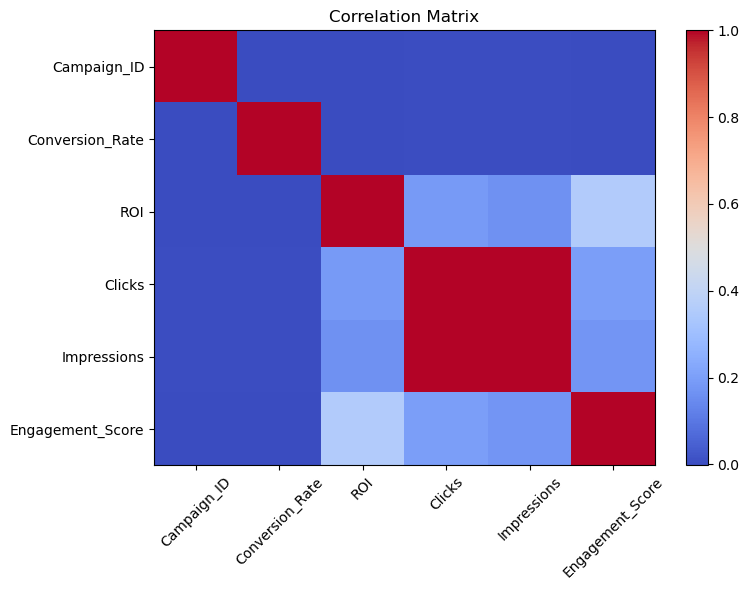

In [12]:
plt.figure(figsize=(8, 6))

plt.imshow(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(df.corr(numeric_only=True).columns)),
    df.corr(numeric_only=True).columns,
    rotation=45
)

plt.yticks(
    range(len(df.corr(numeric_only=True).columns)),
    df.corr(numeric_only=True).columns
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [13]:
print(df.columns.tolist())

['Campaign_ID', 'Target_Audience', 'Campaign_Goal', 'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Location', 'Language', 'Clicks', 'Impressions', 'Engagement_Score', 'Customer_Segment', 'Date', 'Company']


In [14]:
import os

print(os.listdir(r"C:\Users\admin\Downloads"))

['.opera', '03_Python_Functions_Complete_Notes.ipynb', '04_Python_OOP_Complete_Notes.ipynb', '05_Python_File_Exception_Modules_Notes.ipynb', '1_Read_CSV_TSV_Excel_JSON_from_Drive.ipynb', '3_Fetch_Data_from_Local_PostgreSQL_pgAdmin.ipynb', 'Advanced_Notes_and_Password_Manager_Synopsis (1).pdf', 'Advanced_Notes_and_Password_Manager_Synopsis.pdf', 'allmovieland.apk', 'Antigravity-x64.exe', 'archive (1)', 'archive (1).zip', 'archive (2)', 'archive (2).zip', 'archive.zip', 'bde51abc-7584-4fdc-9e57-aafa9b04751f~1.jpg', 'Black and White Clean Professional A4 Resume.pdf', 'boy.jpg', 'burger.jpg', 'ChatGPT Image Jun 26, 2026, 09_10_53 PM.png', 'ChatGPT Image Jun 27, 2026, 06_14_16 PM.png', 'ChatGPT Installer.exe', 'ChromeSetup (1).exe', 'ChromeSetup.exe', 'CHUDU Catalog (1).pdf', 'CHUDU Catalog.pdf', 'deepseek_javascript_20251128_8c87ba.js', 'deepseek_text_20251203_bf1ff5.txt', 'Delinquency_prediction_dataset.xlsx', 'demon-slayer-wallpaper-9.webp', 'desktop.ini', 'dfc.pdf', 'doc.pdf', 'Document

In [15]:
import os

print(os.listdir(r"C:\Users\admin\Downloads\archive (2)"))

['car_purchasing.csv', 'sales data file.csv']


In [16]:
import pandas as pd

# Load Sales dataset
df = pd.read_csv(
    r"C:\Users\admin\Downloads\archive (2)\sales data file.csv"
)

# Display first 5 rows
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [17]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (200, 4)

Columns:
['TV', 'Radio', 'Newspaper', 'Sales']


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [19]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [20]:
# Select input features
X = df[["TV", "Radio", "Newspaper"]]

# Select target variable
y = df["Sales"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target:
0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


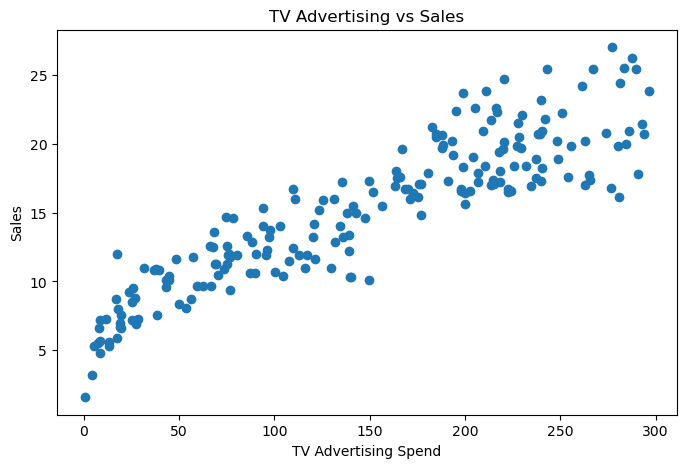

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(df["TV"], df["Sales"])

plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")
plt.title("TV Advertising vs Sales")

plt.show()

In [23]:
from sklearn.linear_model import LinearRegression

# Create Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [24]:
# Predict sales on test data
y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[17.0347724  20.40974033 23.72398873  9.27278518 21.68271879 12.56940161
 21.08119452  8.69035045 17.23701254 16.66657475]


In [25]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

comparison.head(10)

,Actual Sales,Predicted Sales
0,16.9,17.034772
1,22.4,20.409740
2,21.4,23.723989
3,7.3,9.272785
4,24.7,21.682719
5,12.6,12.569402
6,22.3,21.081195
7,8.4,8.690350
8,16.5,17.237013
9,16.1,16.666575


In [26]:
print("Intercept:", model.intercept_)

print("\nCoefficients:")
for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)

Intercept: 4.714126402214131

Coefficients:
TV : 0.05450927083721977
Radio : 0.1009453623929558
Newspaper : 0.00433664682203402


In [27]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Sales Prediction Model Evaluation")
print("----------------------------------")
print("MAE  :", round(mae, 4))
print("MSE  :", round(mse, 4))
print("RMSE :", round(rmse, 4))
print("R²   :", round(r2, 4))

Sales Prediction Model Evaluation
----------------------------------
MAE  : 1.2748
MSE  : 2.9078
RMSE : 1.7052
R²   : 0.9059


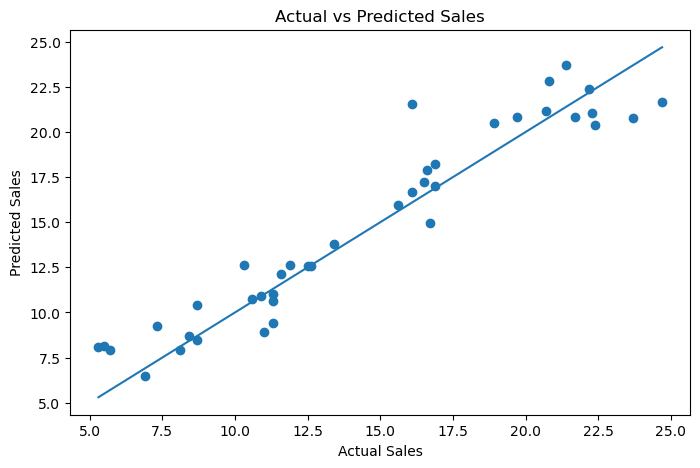

In [28]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

## Business Interpretation

The Linear Regression model predicts sales based on advertising
expenditure on TV, Radio, and Newspaper.

The model performance was evaluated using MAE, MSE, RMSE, and R² Score.

### Business Insights

- Advertising investment can be used to estimate expected sales.
- The model can help businesses plan advertising budgets.
- Sales predictions can support inventory and resource planning.
- The model can help compare the potential impact of different
  advertising channels.
- Prediction errors should be considered when making business decisions.

A lower MAE and RMSE indicate smaller prediction errors, while a higher
R² Score indicates that the model explains a larger proportion of the
variation in sales.

## Conclusion

This case study used supervised Machine Learning to predict sales from
advertising expenditure.

TV, Radio, and Newspaper advertising spending were used as input
features, while Sales was used as the target variable.

A Linear Regression model was trained using the historical data and
evaluated using MAE, MSE, RMSE, and R² Score.

The analysis demonstrates how Regression can help businesses estimate
sales and support data-driven advertising, budgeting, and planning
decisions.

Future improvements could include testing advanced regression models
such as Random Forest Regression, Gradient Boosting, or other ensemble
methods and comparing their performance with Linear Regression.